In [12]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

API_KEY = ""
ACCOUNT_NAME = "seolwon64"

#QiskitRuntimeService.save_account(
#    channel="ibm_quantum_platform",
#    token=API_KEY,
#    name=ACCOUNT_NAME,
#    overwrite=True,
#    set_as_default=False,
#)

# Load saved credentials
service = QiskitRuntimeService(name="seolwon64")

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
# backend = service.backend("ibm_fez")
print(backend.name)


sampler = Sampler(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-09-07 01:11:17,516: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-09-07 01:11:18,034: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-07 01:11:21,888: Using instance: open-instance, plan: open


ibm_fez


In [13]:
# Load the backend sampler
from qiskit.primitives import BackendSamplerV2

# Load the Aer simulator and generate a noise model based on the currently-selected backend.
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# Alternatively, load a fake backend with generic properties and define a simulator.


noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

# You could also define a simulator-based sampler using a generic backend:
# backend_gen = GenericBackendV2(num_qubits=18)
# sampler_gen = BackendSamplerV2(backend=backend_gen)

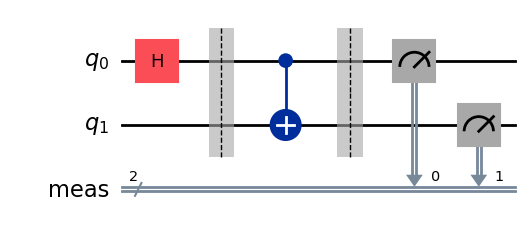

In [14]:
# Step 1: Map

from qiskit import QuantumCircuit

qc = QuantumCircuit(2)


def twobit_function(case: int):
    """
    Generate a valid two-bit function as a `QuantumCircuit`.
    """
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f


# first, convert oracle circuit (above) to a single gate for drawing purposes. otherwise, the
# circuit is too large to display

# you may edit the number inside "twobit_function()" to select among the four valid functions:
# blackbox = twobit_function(2).to_gate()

# blackbox.label = "$U_f$"

qc.h(0)
qc.barrier()
qc.compose(twobit_function(2), inplace=True)
qc.measure_all()


qc.draw("mpl")